<a href="https://colab.research.google.com/github/sidhu2690/MARL/blob/main/Uncertanity_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== training alpha_net ===
[alpha_net] episode 100/1000  avg loss 0.00623
[alpha_net] episode 200/1000  avg loss 0.00309
[alpha_net] episode 300/1000  avg loss 0.00762
[alpha_net] episode 400/1000  avg loss 0.00294
[alpha_net] episode 500/1000  avg loss 0.00568
[alpha_net] episode 600/1000  avg loss 0.00630
[alpha_net] episode 700/1000  avg loss 0.00278
[alpha_net] episode 800/1000  avg loss 0.00389
[alpha_net] episode 900/1000  avg loss 0.00732
[alpha_net] episode 1000/1000  avg loss 0.00370

=== generating g_f training data ===
[g_f data] generated 25/1000 episodes (3750 state samples so far)
[g_f data] generated 50/1000 episodes (7500 state samples so far)
[g_f data] generated 75/1000 episodes (11250 state samples so far)
[g_f data] generated 100/1000 episodes (15000 state samples so far)
[g_f data] generated 125/1000 episodes (18750 state samples so far)
[g_f data] generated 150/1000 episodes (22500 state samples so far)
[g_f data] generated 175/1000 episodes (26250 state samples s

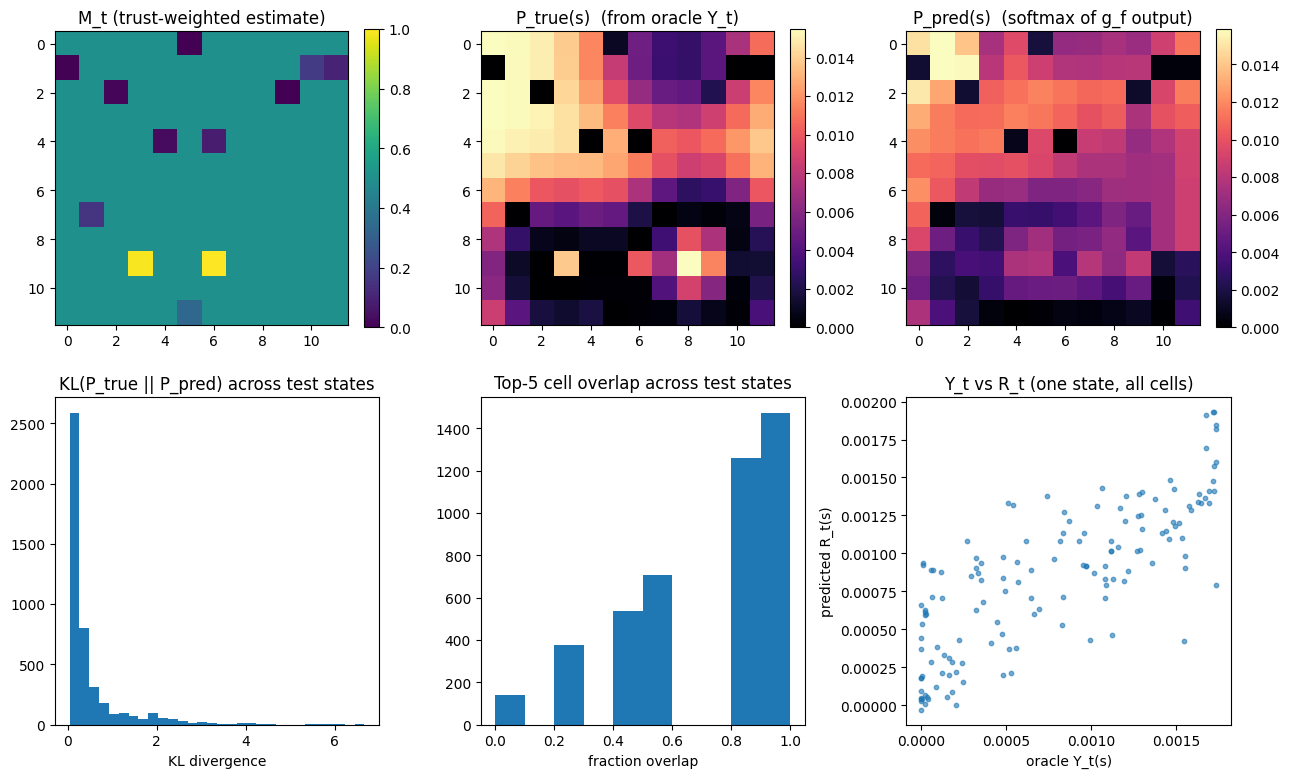

In [13]:
"""
Trust-aware multi-robot mapping: informativeness CNN g_f
==========================================================

Part 1 (reused as-is): trains alpha_net, the trust-weight predictor,
exactly like the reference notebook.

Part 2 (new): trains g_f, a small CNN that looks at the current state of
knowledge  X_t = (M_t, U_t, N_t)  and predicts a raw informativeness map
R_t = g_f(X_t), where R_t(s) should track how much the global
reconstruction error would drop if a reliable (honest) observation were
taken at cell s next.

Training target (oracle):
    E_t            = mean_u (G(u) - M_t(u))^2
    M_{t+1}^(s)    = trust-weighted mean at s after ADDING one hypothetical
                     honest observation there (alpha = 1, since it is a
                     known-reliable sample by construction)
    E_{t+1}(s)     = mean_u (G(u) - M_{t+1}^(s)(u))^2   [only cell s changes]
    Y_t(s)         = clip(E_t - E_{t+1}(s), 0, None)

  loss = mean_s (R_t(s) - Y_t(s))^2

No adversarial identities or robot positions are given to g_f -- only the
three maps. Robot identity is only used (as in the reference code) to
generate realistic honest/adversarial reports while building M_t, U_t, N_t.

Validation:
  P_true(s) = Y_t(s) / sum(Y_t)                 [Y_t is already >= 0]
  P_pred(s) = clip(R_t(s), 0, None) / sum(...)  [R_t is regressed directly
                                                  onto Y_t's small scale, so
                                                  sum-normalizing keeps it
                                                  comparable; a softmax would
                                                  need order-1 logits and
                                                  would just flatten this]
  compared via KL(P_true || P_pred) and top-k cell overlap.
"""

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Shared environment config (same style/scale as the reference notebook)
# ----------------------------------------------------------------------
GRID = 12
N_ROBOTS = 12
ADV_FRAC = 0.34
STEPS = 150
EPSILON = 0.05
CONTRA_THRESH = 0.2
SEED = 40

rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)


def make_true_map(grid):
    xs, ys = np.meshgrid(np.arange(grid), np.arange(grid))
    field = np.zeros((grid, grid))
    for _ in range(5):
        cx, cy = rng.uniform(0, grid, 2)
        amp = rng.uniform(0.5, 1.0)
        sigma = rng.uniform(1.5, 3.5)
        field += amp * np.exp(-((xs - cx) ** 2 + (ys - cy) ** 2) / (2 * sigma ** 2))
    field = (field - field.min()) / (field.max() - field.min() + 1e-8)
    return field


TRUE_MAP = make_true_map(GRID)


def random_walk(grid, steps):
    pos = rng.integers(0, grid, size=2)
    cells = []
    for _ in range(steps):
        while True:
            move = rng.choice([-1, 0, 1], size=2)
            new_pos = np.clip(pos + move, 0, grid - 1)
            if not np.array_equal(new_pos, pos):
                break
        pos = new_pos
        cells.append(tuple(pos))
    return cells


def make_adv_mask(n_robots, adv_frac):
    n_adv = int(n_robots * adv_frac)
    mask = np.array([False] * (n_robots - n_adv) + [True] * n_adv)
    rng.shuffle(mask)
    return mask


def report_value(true_val, adversarial):
    if adversarial:
        val = true_val + rng.choice([-1, 1]) * rng.uniform(0.3, 0.6) + rng.normal(0, 0.1)
    else:
        val = true_val + rng.normal(0, 0.02)
    return float(np.clip(val, 0, 1))


# ----------------------------------------------------------------------
# Part 1: alpha_net (trust-weight predictor) -- unchanged from reference
# ----------------------------------------------------------------------
class AlphaNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid(),
        )

    def forward(self, feats):
        return self.net(feats).squeeze(-1)


def train_alpha_net(episodes=400, lr=2e-3):
    alpha_net = AlphaNet()
    optimizer = torch.optim.Adam(alpha_net.parameters(), lr=lr)
    loss_history = []

    for ep in range(episodes):
        is_adv = make_adv_mask(N_ROBOTS, ADV_FRAC)
        walks = [random_walk(GRID, STEPS) for _ in range(N_ROBOTS)]
        c = np.zeros(N_ROBOTS)
        D_sum = np.zeros(N_ROBOTS)
        D_n = np.zeros(N_ROBOTS)
        cell_reports = {}
        ep_loss = 0.0

        for t in range(STEPS):
            touched_cells = set()
            for i in range(N_ROBOTS):
                cell = walks[i][t]
                r_i = report_value(TRUE_MAP[cell], is_adv[i])
                others = cell_reports.get(cell, [])
                if others:
                    residuals = [abs(r_i - r_j) for _, r_j in others]
                    D_sum[i] += float(np.mean(residuals))
                    D_n[i] += 1
                    for j, r_j in others:
                        if abs(r_i - r_j) > CONTRA_THRESH:
                            c[i] += 1
                            c[j] += 1
                cell_reports.setdefault(cell, []).append((i, r_i))
                touched_cells.add(cell)

            mu_c, sigma_c = c.mean(), c.std()
            z = (c - mu_c) / (sigma_c + EPSILON)
            D = np.divide(D_sum, D_n, out=np.zeros_like(D_sum), where=D_n > 0)
            c_norm = c / (t + 1)

            feats = torch.tensor(np.stack([c_norm, z, D], axis=1), dtype=torch.float32)
            alpha = alpha_net(feats)

            step_loss = 0.0
            for cell in touched_cells:
                reports = cell_reports[cell]
                idx = torch.tensor([r for r, _ in reports])
                vals = torch.tensor([v for _, v in reports], dtype=torch.float32)
                a = alpha[idx]
                M = (a * vals).sum() / (a.sum() + EPSILON)
                step_loss = step_loss + (TRUE_MAP[cell] - M) ** 2
            step_loss = step_loss / len(touched_cells)

            optimizer.zero_grad()
            step_loss.backward()
            optimizer.step()
            ep_loss += step_loss.item()

        loss_history.append(ep_loss / STEPS)
        if (ep + 1) % 100 == 0:
            print(f"[alpha_net] episode {ep+1}/{episodes}  avg loss {loss_history[-1]:.5f}")

    return alpha_net, loss_history


# ----------------------------------------------------------------------
# Part 2: rollout that produces (M_t, U_t, N_t) -> Y_t training pairs
# ----------------------------------------------------------------------
PRIOR = 0.5     # M_t(s) prior for never-observed cells
Y_SCALE = 2000.0  # rescales the (tiny) regression target for stable training;
                   # cancels out again once R_t is sum-normalized into a
                   # probability map, so it does not change the final P_t


def rollout_episode(alpha_net):
    """Runs one episode and yields (X_t, Y_t) at every time step.

    X_t: array (3, GRID, GRID) = stacked (M_t, U_t, N_t)
    Y_t: array (GRID, GRID), the oracle informativeness map
    """
    is_adv = make_adv_mask(N_ROBOTS, ADV_FRAC)
    walks = [random_walk(GRID, STEPS) for _ in range(N_ROBOTS)]
    c = np.zeros(N_ROBOTS)
    D_sum = np.zeros(N_ROBOTS)
    D_n = np.zeros(N_ROBOTS)
    cell_reports = {}

    xs, ys = [], []

    for t in range(STEPS):
        for i in range(N_ROBOTS):
            cell = walks[i][t]
            r_i = report_value(TRUE_MAP[cell], is_adv[i])
            others = cell_reports.get(cell, [])
            if others:
                residuals = [abs(r_i - r_j) for _, r_j in others]
                D_sum[i] += float(np.mean(residuals))
                D_n[i] += 1
                for j, r_j in others:
                    if abs(r_i - r_j) > CONTRA_THRESH:
                        c[i] += 1
                        c[j] += 1
            cell_reports.setdefault(cell, []).append((i, r_i))

        mu_c, sigma_c = c.mean(), c.std()
        z = (c - mu_c) / (sigma_c + EPSILON)
        D = np.divide(D_sum, D_n, out=np.zeros_like(D_sum), where=D_n > 0)
        c_norm = c / (t + 1)

        feats = torch.tensor(np.stack([c_norm, z, D], axis=1), dtype=torch.float32)
        with torch.no_grad():
            alpha = alpha_net(feats).numpy()

        # trust-weighted running sums per cell -> full (M_t, U_t, N_t) maps
        W_sum = np.zeros((GRID, GRID))
        A_sum = np.zeros((GRID, GRID))
        N_map = np.zeros((GRID, GRID))
        for cell, reports in cell_reports.items():
            idx = np.array([r for r, _ in reports])
            vals = np.array([v for _, v in reports])
            a = alpha[idx]
            W_sum[cell] = (a * vals).sum()
            A_sum[cell] = a.sum()
            N_map[cell] = len(reports)

        M_t = np.where(A_sum > 0, W_sum / np.maximum(A_sum, 1e-8), PRIOR)
        # U_t, N_t are unbounded and keep growing with t, while M_t stays in
        # [0, 1]; dividing by the elapsed step count (t+1) puts all three
        # input channels on a comparable scale, the same trick used for
        # c_norm in alpha_net's features.
        U_t = A_sum / (t + 1)
        N_t = N_map / (t + 1)

        # oracle target Y_t(s): drop in global error from one hypothetical
        # honest (alpha = 1) observation at each candidate cell s
        err_old = (TRUE_MAP - M_t) ** 2
        honest_noise = rng.normal(0, 0.02, size=(GRID, GRID))
        r_new = np.clip(TRUE_MAP + honest_noise, 0, 1)
        M_next = (W_sum + r_new) / (A_sum + 1.0)
        err_new = (TRUE_MAP - M_next) ** 2

        Y_t = np.clip((err_old - err_new) / (GRID * GRID), 0, None)

        xs.append(np.stack([M_t, U_t, N_t]).astype(np.float32))
        ys.append(Y_t.astype(np.float32))

    return xs, ys


# ----------------------------------------------------------------------
# Part 3: g_f -- the informativeness CNN
# ----------------------------------------------------------------------
class GNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)  # raw, unrestricted, Y_SCALE-scaled output


def predict_R(gnet, X_t):
    """Runs g_f on a single state X_t (3, GRID, GRID) and returns R_t on the
    same scale as the oracle Y_t (undoes the Y_SCALE used during training)."""
    with torch.no_grad():
        raw = gnet(torch.tensor(X_t, dtype=torch.float32).unsqueeze(0)).squeeze(0)
    return (raw / Y_SCALE).numpy()


def build_dataset(alpha_net, episodes):
    X_all, Y_all = [], []
    for ep in range(episodes):
        xs, ys = rollout_episode(alpha_net)
        X_all.extend(xs)
        Y_all.extend(ys)
        if (ep + 1) % 25 == 0:
            print(f"[g_f data] generated {ep+1}/{episodes} episodes "
                  f"({len(X_all)} state samples so far)")
    X = torch.tensor(np.stack(X_all), dtype=torch.float32)
    Y = torch.tensor(np.stack(Y_all), dtype=torch.float32) * Y_SCALE
    return X, Y


def train_gnet(X, Y, epochs=10, lr=1e-3, batch_size=64):
    gnet = GNet()
    optimizer = torch.optim.Adam(gnet.parameters(), lr=lr)
    n = X.shape[0]
    loss_history = []

    for epoch in range(epochs):
        perm = torch.randperm(n)
        epoch_loss = 0.0
        n_batches = 0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X[idx], Y[idx]
            pred = gnet(xb)
            loss = ((pred - yb) ** 2).mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        loss_history.append(epoch_loss / n_batches)
        print(f"[g_f train] epoch {epoch+1}/{epochs}  avg loss {loss_history[-1]:.6f}")

    return gnet, loss_history


# ----------------------------------------------------------------------
# Part 4: validation -- compare predicted vs oracle probability maps
# ----------------------------------------------------------------------
def normalize_nonneg(y):
    """Sum-normalize a non-negative map into a probability map.

    This is the natural choice here: g_f is trained by direct regression
    against Y_t, which is already >= 0 and on the same small scale, so its
    output R_t sits on that same scale too. A softmax (built for
    unconstrained, order-1 logits) would flatten a signal this small into
    an almost uniform distribution regardless of the true ranking, so we
    clip any small negative numerical noise to 0 and normalize by the sum
    instead -- the "divide by sum" branch of P_t(s) = R_t(s) / sum(R_t).
    """
    y = np.clip(y, 0, None)
    s = y.sum()
    if s <= 1e-12:
        return np.full_like(y, 1.0 / y.size)
    return y / s


def kl_divergence(p_true, p_pred, eps=1e-8):
    p_true = np.clip(p_true, eps, None)
    p_pred = np.clip(p_pred, eps, None)
    return float(np.sum(p_true * np.log(p_true / p_pred)))


def topk_overlap(y_true, r_pred, k=5):
    true_top = set(np.argsort(y_true.reshape(-1))[-k:])
    pred_top = set(np.argsort(r_pred.reshape(-1))[-k:])
    return len(true_top & pred_top) / k


def evaluate(gnet, alpha_net, episodes=20, k=5):
    kls, overlaps = [], []
    sample_X, sample_Y, sample_R = None, None, None

    for ep in range(episodes):
        xs, ys = rollout_episode(alpha_net)
        for X_t, Y_t in zip(xs, ys):
            R_t = predict_R(gnet, X_t)

            p_true = normalize_nonneg(Y_t)
            p_pred = normalize_nonneg(R_t)

            kls.append(kl_divergence(p_true, p_pred))
            overlaps.append(topk_overlap(Y_t, R_t, k=k))

            if sample_X is None and Y_t.sum() > 1e-6:
                sample_X, sample_Y, sample_R = X_t, Y_t, R_t

    print(f"[g_f eval] mean KL(true||pred) = {np.mean(kls):.4f}  "
          f"mean top-{k} overlap = {np.mean(overlaps):.3f}")
    return kls, overlaps, (sample_X, sample_Y, sample_R)


def plot_validation(kls, overlaps, sample, k=5):
    sample_X, sample_Y, sample_R = sample
    p_true = normalize_nonneg(sample_Y)
    p_pred = normalize_nonneg(sample_R)

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))

    axes[0, 0].imshow(sample_X[0], cmap="viridis")
    axes[0, 0].set_title("M_t (trust-weighted estimate)")

    axes[0, 1].imshow(p_true, cmap="magma")
    axes[0, 1].set_title("P_true(s)  (from oracle Y_t)")

    axes[0, 2].imshow(p_pred, cmap="magma")
    axes[0, 2].set_title("P_pred(s)  (softmax of g_f output)")

    axes[1, 0].hist(kls, bins=30)
    axes[1, 0].set_title("KL(P_true || P_pred) across test states")
    axes[1, 0].set_xlabel("KL divergence")

    axes[1, 1].hist(overlaps, bins=np.linspace(0, 1, 11))
    axes[1, 1].set_title(f"Top-{k} cell overlap across test states")
    axes[1, 1].set_xlabel("fraction overlap")

    axes[1, 2].scatter(sample_Y.reshape(-1), sample_R.reshape(-1), s=10, alpha=0.6)
    axes[1, 2].set_xlabel("oracle Y_t(s)")
    axes[1, 2].set_ylabel("predicted R_t(s)")
    axes[1, 2].set_title("Y_t vs R_t (one state, all cells)")

    for ax in axes[0]:
        plt.colorbar(ax.images[0], ax=ax, fraction=0.046)

    plt.tight_layout()
    plt.savefig("gfunc_validation.png", dpi=130)
    print("saved plot to gfunc_validation.png")


# ----------------------------------------------------------------------
# Run everything
# ----------------------------------------------------------------------
if __name__ == "__main__":
    ALPHA_EPISODES = 1000
    G_DATA_EPISODES = 1000
    G_EPOCHS = 100
    EVAL_EPISODES = 30

    print("=== training alpha_net ===")
    alpha_net, alpha_loss = train_alpha_net(episodes=ALPHA_EPISODES)

    print("\n=== generating g_f training data ===")
    X, Y = build_dataset(alpha_net, episodes=G_DATA_EPISODES)
    print("dataset:", X.shape, Y.shape, " Y stats:",
          float(Y.min()), float(Y.max()), float(Y.mean()))

    print("\n=== training g_f ===")
    gnet, g_loss = train_gnet(X, Y, epochs=G_EPOCHS)

    print("\n=== validating g_f ===")
    kls, overlaps, sample = evaluate(gnet, alpha_net, episodes=EVAL_EPISODES)
    plot_validation(kls, overlaps, sample)

    torch.save(alpha_net.state_dict(), "alpha_net.pt")
    torch.save(gnet.state_dict(), "gnet.pt")
    print("\nsaved alpha_net.pt and gnet.pt")